In [1]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv.zip to creditcard.csv.zip


In [2]:
import zipfile

with zipfile.ZipFile('creditcard.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [3]:
import os

os.listdir()

['.config', 'creditcard.csv.zip', 'creditcard.csv', 'sample_data']

In [4]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


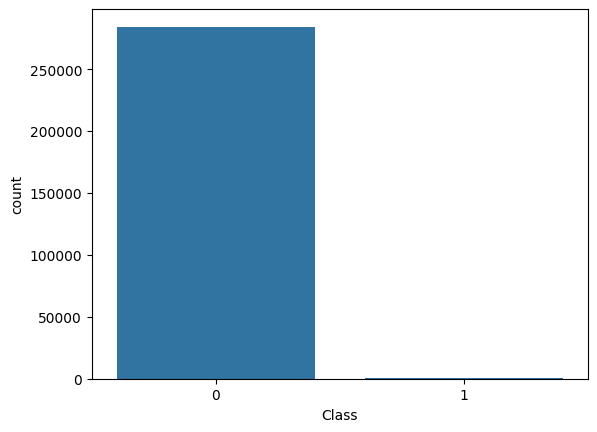

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.show()

In [11]:
print(df['Class'].value_counts(normalize=True)*100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [12]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


# Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])


In [14]:
df.drop('Time', axis=1, inplace=True)

In [15]:
X = df.drop('Class', axis=1)
y = df['Class']

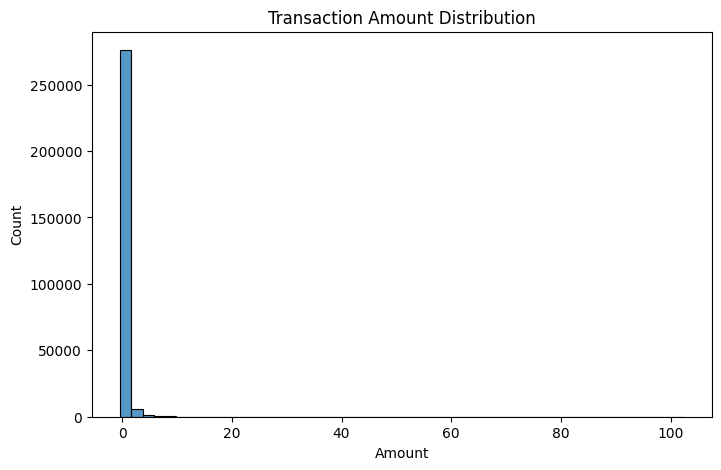

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.show()

In [17]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,-0.000234,0.999942,-0.353229,-0.330640,-0.265271,-0.045177,102.362243
1,492.0,0.135382,1.026242,-0.353229,-0.349231,-0.316247,0.070128,8.146182


In [18]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
print(y_train.value_counts())
print(y_test.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [23]:
lr_smote = LogisticRegression(max_iter=1000)

lr_smote.fit(X_train_smote, y_train_smote)

pred_smote = lr_smote.predict(X_test)

print(classification_report(y_test, pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



# Random Forest (Without SMOTE)

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



# Random Forest (With SMOTE)

In [25]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

pred_rf_smote = rf_smote.predict(X_test)

print(classification_report(y_test, pred_rf_smote))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



# XG Boost

In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.94      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



# ROC-AUC Score

In [27]:
from sklearn.metrics import roc_auc_score

rf_probs = rf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, rf_probs)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9528106983508091


In [29]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

importance.head(10)

,Feature,Importance
16,V17,0.134630
11,V12,0.125775
13,V14,0.122273
9,V10,0.089324
15,V16,0.080660
10,V11,0.080381
6,V7,0.033882
3,V4,0.031554
8,V9,0.030702
17,V18,0.030525


# Deployment

In [30]:
import joblib

joblib.dump(rf, 'fraud_detection_model.pkl')

['fraud_detection_model.pkl']

In [31]:
import os

os.listdir()

['.config',
 'creditcard.csv.zip',
 'creditcard.csv',
 'fraud_detection_model.pkl',
 'sample_data']

In [32]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load("fraud_detection_model.pkl")

st.title("Credit Card Fraud Detection")

uploaded_file = st.file_uploader(
    "Upload transaction CSV",
    type=["csv"]
)

if uploaded_file is not None:
    data = pd.read_csv(uploaded_file)

    prediction = model.predict(data)

    data["Prediction"] = prediction

    st.write(data)

    st.write(
        f"Fraud Transactions: {(prediction==1).sum()}"
    )

Writing app.py


In [33]:
!ls

app.py		creditcard.csv.zip	   sample_data
creditcard.csv	fraud_detection_model.pkl


In [ ]:
from google.colab import drive
drive.mount('/content/drive')